In [1]:
from datetime import datetime

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_selection import (
    RFECV,
)
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split, KFold
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression

KeyboardInterrupt: 

In [ ]:
DATA_PREFIX = "../data"
OUTPUT_PREFIX = "../output"

EXTRACT_TRAIN_PARQUET = f"{OUTPUT_PREFIX}/extract_train_v2.parquet"
EXTRACT_TEST_PARQUET = f"{OUTPUT_PREFIX}/extract_test_v2.parquet"
SUBMISSION_CSV = f"{DATA_PREFIX}/sample_submission.csv"


In [ ]:
BANDS_S2 = ["BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2"]
# BANDS_S2_DIST = [f"{b}_DIST" for b in BANDS_S2]
BANDS_S1 = ["VV", "VH"]
BANDS_CHM = [
    # "CHM",
    "CHM_META",
    # "CHM_ETH",
    "CHM_ALS",
]
BANDS_TERRAIN = [
    # "elevation",
    "slope",
    "aspect",
    "tpi",
    "tri",
    "hillshade",
]
BANDS_LST = ["LST"]
BANDS_TREE = ["CANOPY_DENSITY", "TREE_RATIO"]
BANDS_AGB = ["AGB_GEDI", "AGB_ALS"]
# BANDS_S1_DIST = [f"{b}_DIST" for b in BANDS_S1]

INDICES = [
    dict(name="NDVI", band1="NIR", band2="RED"),
    dict(name="NDMI", band1="NIR", band2="SWIR1"),
    dict(name="NBR", band1="NIR", band2="SWIR2"),
    dict(name="NBR2", band1="SWIR1", band2="SWIR2"),
    dict(name="NDWI", band1="GREEN", band2="NIR"),
    dict(name="MNDWI", band1="GREEN", band2="SWIR1"),
    dict(name="MNDWI2", band1="GREEN", band2="SWIR2"),
    dict(name="RVI", band1="VV", band2="VH"),
]

INDICES_BANDS = [indi["name"] for indi in INDICES]
# INDICES_BANDS_DIST = [f"{b}_DIST" for b in INDICES_BANDS]

PREDICTORS = [
    *BANDS_S2,
    *BANDS_S1,
    *INDICES_BANDS,
    *BANDS_CHM,
    *BANDS_TREE,
    *BANDS_TERRAIN,
    *BANDS_LST,
    *BANDS_AGB
    # *BANDS_S2_DIST,
    # *BANDS_S1_DIST,
    # *INDICES_BANDS_DIST,
]

LABEL = "biomass"

PREDICTORS

['BLUE',
 'GREEN',
 'RED',
 'NIR',
 'SWIR1',
 'SWIR2',
 'VV',
 'VH',
 'NDVI',
 'NDMI',
 'NBR',
 'NBR2',
 'NDWI',
 'MNDWI',
 'MNDWI2',
 'RVI',
 'CHM_META',
 'CHM_ALS',
 'CANOPY_DENSITY',
 'TREE_RATIO',
 'slope',
 'aspect',
 'tpi',
 'tri',
 'hillshade',
 'LST',
 'AGB_GEDI',
 'AGB_ALS']

In [ ]:
# load parquet extracted
train_df = gpd.read_parquet(EXTRACT_TRAIN_PARQUET).dropna()
train_df

,x,y,year,biomass,tile_id,geometry,BLUE,GREEN,RED,NIR,...,A57,A58,A59,A60,A61,A62,A63,AGB_GEDI,AGB_ALS,TREE_RATIO
0,3137124.7416963745,1810803.9191588927,2020,28.742064,038052,POINT (-3.54712 38.43217),366.0,588.0,620.0,2545.0,...,-14,-43,-60,56,-10,8,-36,113.301270,56.061787,0.259686
1,3138084.7416963745,1808543.9191588927,2020,61.379017,038052,POINT (-3.53221 38.41357),305.0,540.0,401.0,3402.0,...,-42,-37,-55,52,-38,31,39,73.137436,75.136459,0.270767
2,3136834.7416963745,1809903.9191588927,2020,41.445705,038052,POINT (-3.54874 38.42368),464.0,710.0,748.0,2929.0,...,-31,-27,-62,52,-26,26,0,74.259979,59.050060,0.278183
3,3137594.7416963745,1810823.9191588927,2020,25.911734,038052,POINT (-3.54186 38.4331),622.0,848.0,1139.0,2380.0,...,20,-35,-47,66,-32,32,16,94.649872,66.291756,0.245272
4,3137914.7416963745,1808923.9191588927,2020,40.892021,038052,POINT (-3.53481 38.41668),281.0,514.0,387.0,2421.0,...,43,-54,-48,57,-21,-29,14,74.906807,56.946735,0.258520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5148498,3111814.7416963745,2243943.9191588927,2019,96.743500,035805,POINT (-4.70358 42.23347),371.0,607.0,566.0,2937.0,...,-30,-60,-53,50,-57,0,-41,80.114174,82.793846,0.421154
5148499,3111664.7416963745,2243933.9191588927,2019,58.634174,035805,POINT (-4.70534 42.23312),882.0,1252.0,1425.0,3500.0,...,-10,-51,-49,58,-61,18,-19,68.616600,63.931862,0.406098
5148501,3113104.7416963745,2243803.9191588927,2019,118.166924,035805,POINT (-4.68791 42.2345),380.0,564.0,578.0,3241.0,...,-19,-64,-40,40,-64,-31,-35,86.218414,93.326202,0.181319
5148502,3113074.7416963745,2243833.9191588927,2019,104.021767,035805,POINT (-4.68834 42.23471),307.0,510.0,479.0,3084.0,...,-22,-69,-47,37,-62,-32,-29,88.159515,96.633919,0.285560


In [ ]:
# Generating indices
def generate_indices(table, band_suffix=""):
    for index_dict in INDICES:
        name = f"{index_dict['name']}{band_suffix}"
        band1 = f"{index_dict['band1']}{band_suffix}"
        band2 = f"{index_dict['band2']}{band_suffix}"
        table[name] = (
            ((table[band1] / 1e4) - (table[band2] / 1e4))
            / ((table[band1] / 1e4) + (table[band2] / 1e4))
            * 1e4
        )


generate_indices(train_df)
# generate_indices(train_df, "_DIST")

train_df

,x,y,year,biomass,tile_id,geometry,BLUE,GREEN,RED,NIR,...,AGB_ALS,TREE_RATIO,NDVI,NDMI,NBR,NBR2,NDWI,MNDWI,MNDWI2,RVI
0,3137124.7416963745,1810803.9191588927,2020,28.742064,038052,POINT (-3.54712 38.43217),366.0,588.0,620.0,2545.0,...,56.061787,0.259686,6082.148499,953.303206,3286.348212,2408.500590,-6246.409192,-5628.252788,-3724.653148,5634.005764
1,3138084.7416963745,1808543.9191588927,2020,61.379017,038052,POINT (-3.53221 38.41357),305.0,540.0,401.0,3402.0,...,75.136459,0.270767,7891.138575,2368.660244,5231.699127,3268.015171,-7260.273973,-5907.540735,-3271.028037,5745.654163
2,3136834.7416963745,1809903.9191588927,2020,41.445705,038052,POINT (-3.54874 38.42368),464.0,710.0,748.0,2929.0,...,59.050060,0.278183,5931.465869,908.752328,3172.925568,2331.396817,-6097.829074,-5493.494129,-3626.570916,5230.875258
3,3137594.7416963745,1810823.9191588927,2020,25.911734,038052,POINT (-3.54186 38.4331),622.0,848.0,1139.0,2380.0,...,66.291756,0.245272,3526.570048,-428.312890,1646.684610,2060.465116,-4745.972739,-5071.200232,-3362.035225,4729.829756
4,3137914.7416963745,1808923.9191588927,2020,40.892021,038052,POINT (-3.53481 38.41668),281.0,514.0,387.0,2421.0,...,56.946735,0.258520,7243.589744,2396.313364,4677.174901,2568.768515,-6497.444634,-4857.428714,-2614.942529,4161.585366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5148498,3111814.7416963745,2243943.9191588927,2019,96.743500,035805,POINT (-4.70358 42.23347),371.0,607.0,566.0,2937.0,...,82.793846,0.421154,6768.484156,1165.177723,3695.500117,2644.178455,-6574.492099,-5858.068918,-3802.960694,4750.430293
5148499,3111664.7416963745,2243933.9191588927,2019,58.634174,035805,POINT (-4.70534 42.23312),882.0,1252.0,1425.0,3500.0,...,63.931862,0.406098,4213.197970,1301.259283,3425.393172,2223.230490,-4730.639731,-3654.333502,-1557.653405,6197.623515
5148501,3113104.7416963745,2243803.9191588927,2019,118.166924,035805,POINT (-4.68791 42.2345),380.0,564.0,578.0,3241.0,...,93.326202,0.181319,6973.029589,1990.381058,4546.678636,2810.650888,-7035.479632,-5866.617809,-3659.359191,4710.860367
5148502,3113074.7416963745,2243833.9191588927,2019,104.021767,035805,POINT (-4.68834 42.23471),307.0,510.0,479.0,3084.0,...,96.633919,0.285560,7311.254561,2233.240777,4431.445952,2439.644219,-7161.936561,-5867.098865,-4000.000000,5334.750266


In [ ]:
train_df_filter = train_df[(train_df["BLUE"] > 0) & (train_df["VV"] > 0)]
train_df_filter

,x,y,year,biomass,tile_id,geometry,BLUE,GREEN,RED,NIR,...,AGB_ALS,TREE_RATIO,NDVI,NDMI,NBR,NBR2,NDWI,MNDWI,MNDWI2,RVI
0,3137124.7416963745,1810803.9191588927,2020,28.742064,038052,POINT (-3.54712 38.43217),366.0,588.0,620.0,2545.0,...,56.061787,0.259686,6082.148499,953.303206,3286.348212,2408.500590,-6246.409192,-5628.252788,-3724.653148,5634.005764
1,3138084.7416963745,1808543.9191588927,2020,61.379017,038052,POINT (-3.53221 38.41357),305.0,540.0,401.0,3402.0,...,75.136459,0.270767,7891.138575,2368.660244,5231.699127,3268.015171,-7260.273973,-5907.540735,-3271.028037,5745.654163
2,3136834.7416963745,1809903.9191588927,2020,41.445705,038052,POINT (-3.54874 38.42368),464.0,710.0,748.0,2929.0,...,59.050060,0.278183,5931.465869,908.752328,3172.925568,2331.396817,-6097.829074,-5493.494129,-3626.570916,5230.875258
3,3137594.7416963745,1810823.9191588927,2020,25.911734,038052,POINT (-3.54186 38.4331),622.0,848.0,1139.0,2380.0,...,66.291756,0.245272,3526.570048,-428.312890,1646.684610,2060.465116,-4745.972739,-5071.200232,-3362.035225,4729.829756
4,3137914.7416963745,1808923.9191588927,2020,40.892021,038052,POINT (-3.53481 38.41668),281.0,514.0,387.0,2421.0,...,56.946735,0.258520,7243.589744,2396.313364,4677.174901,2568.768515,-6497.444634,-4857.428714,-2614.942529,4161.585366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5148498,3111814.7416963745,2243943.9191588927,2019,96.743500,035805,POINT (-4.70358 42.23347),371.0,607.0,566.0,2937.0,...,82.793846,0.421154,6768.484156,1165.177723,3695.500117,2644.178455,-6574.492099,-5858.068918,-3802.960694,4750.430293
5148499,3111664.7416963745,2243933.9191588927,2019,58.634174,035805,POINT (-4.70534 42.23312),882.0,1252.0,1425.0,3500.0,...,63.931862,0.406098,4213.197970,1301.259283,3425.393172,2223.230490,-4730.639731,-3654.333502,-1557.653405,6197.623515
5148501,3113104.7416963745,2243803.9191588927,2019,118.166924,035805,POINT (-4.68791 42.2345),380.0,564.0,578.0,3241.0,...,93.326202,0.181319,6973.029589,1990.381058,4546.678636,2810.650888,-7035.479632,-5866.617809,-3659.359191,4710.860367
5148502,3113074.7416963745,2243833.9191588927,2019,104.021767,035805,POINT (-4.68834 42.23471),307.0,510.0,479.0,3084.0,...,96.633919,0.285560,7311.254561,2233.240777,4431.445952,2439.644219,-7161.936561,-5867.098865,-4000.000000,5334.750266


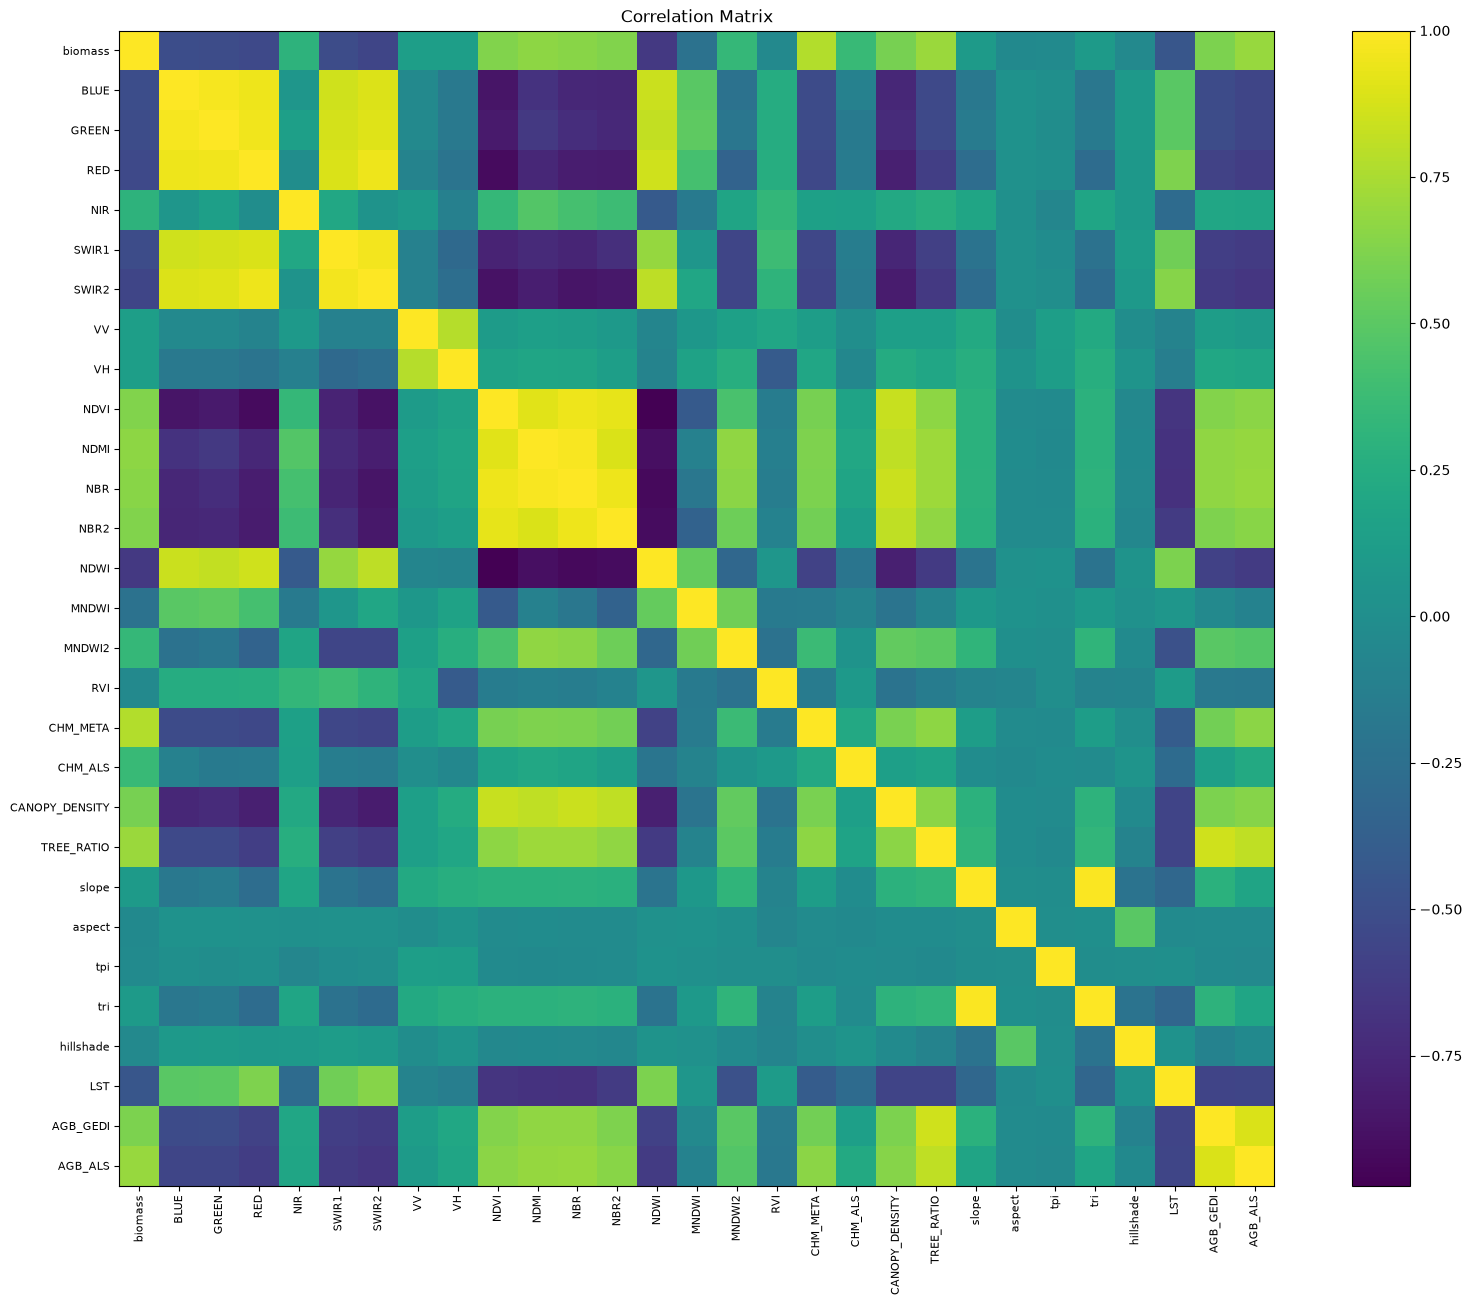

In [ ]:
# generate correlation matrix
correlation = train_df[[LABEL, *PREDICTORS]].corr()

plt.figure(figsize=(20, 15))
plt.imshow(correlation)
plt.title("Correlation Matrix")
plt.xticks(range(len([LABEL, *PREDICTORS])), [LABEL, *PREDICTORS], size=8, rotation=90)
plt.yticks(range(len([LABEL, *PREDICTORS])), [LABEL, *PREDICTORS], size=8)
plt.colorbar()
plt.show()


In [ ]:
# split train and test data
train, test = train_test_split(train_df_filter, test_size=0.5)

In [ ]:
# train limit sample
train_limit = train.sample(10_000)
test_limit = test.sample(1000)
train_limit

,x,y,year,biomass,tile_id,geometry,BLUE,GREEN,RED,NIR,...,AGB_ALS,TREE_RATIO,NDVI,NDMI,NBR,NBR2,NDWI,MNDWI,MNDWI2,RVI
3867503,3527834.7416963745,2015853.9191588927,2016,0.490738,076991,POINT (0.61712 40.79816),578.0,997.0,1242.0,2691.0,...,87.138069,0.240881,3684.210526,-610.607118,1254.705144,1851.130164,-4593.275488,-5061.911838,-3542.746114,5257.611241
3278673,3694504.7416963745,2120063.9191588927,2016,222.136902,093769,POINT (2.46351 41.90204),198.0,374.0,207.0,3333.0,...,155.180435,0.766821,8830.508475,4962.962963,7555.965236,4148.802018,-7982.195846,-5000.000000,-1073.985680,5622.228020
4649802,3224804.7416963745,2215183.9191588927,2019,70.955437,046858,POINT (-3.29757 42.16758),503.0,768.0,852.0,2569.0,...,82.587440,0.389222,5019.000292,1317.180617,3027.383367,1781.231321,-5397.063230,-4392.113910,-2832.477835,5369.335816
2747939,3040504.7416963745,2251083.9191588927,2021,131.762360,028631,POINT (-5.56738 42.16772),266.0,458.0,401.0,2825.0,...,111.226738,0.218072,7513.949163,2431.243124,5155.579399,3114.754098,-7209.869022,-5794.306703,-3269.654666,5846.153846
3931119,3527704.7416963745,2017813.9191588927,2016,15.642389,076991,POINT (0.61296 40.81559),931.0,1439.0,1752.0,3234.0,...,11.545478,0.116551,2972.322503,-579.667929,697.982137,1272.501552,-3841.215493,-4324.590810,-3229.828276,5936.305732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3085211,3712534.7416963745,2100653.9191588927,2016,67.731171,095557,POINT (2.70017 41.74357),253.0,423.0,358.0,2037.0,...,128.371979,0.286306,7010.438413,1046.637744,4043.433299,3129.224652,-6560.975610,-5920.925747,-3426.573427,4544.456641
4897388,3176064.7416963745,2249053.9191588927,2019,37.191681,042085,POINT (-3.94811 42.38858),436.0,675.0,715.0,2445.0,...,41.168423,0.337253,5474.683544,195.996664,2411.167513,2225.689028,-5673.076923,-5538.664904,-3778.801843,6145.161290
174729,3215354.7416963745,2321433.9191588927,2019,148.839920,045997,POINT (-3.62623 43.09448),296.0,693.0,261.0,5271.0,...,149.384933,0.362754,9056.399132,3705.148206,6638.257576,3889.845095,-7676.056338,-5549.132948,-2116.040956,6366.265060
220676,3645664.7416963745,2127533.9191588927,2016,97.037788,088988,POINT (1.87063 41.92339),225.0,527.0,428.0,2010.0,...,101.019562,0.519934,6488.925349,1276.297335,4100.315679,2979.966611,-5845.486795,-4937.560038,-2295.321637,3651.376147


In [ ]:
min_features_to_select = 3
cv = KFold(n_splits=5, shuffle=True, random_state=42)
rfecv = RFECV(
    estimator=LinearRegression(),
    step=1,
    cv=cv,
    min_features_to_select=min_features_to_select,
    scoring="neg_mean_squared_error",
)
rfecv.fit(train_limit[PREDICTORS], train_limit[LABEL])

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LinearRegression()
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",3
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.",'neg_mean_squared_error'
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"cv_results_ cv_results_: dict of ndarraysAll arrays (values of the dictionary) are sorted in ascending orderby the number of features used (i.e., the first element of the arrayrepresents the models that used the least number of features, while thelast element represents the models that used all available features)... versionadded:: 1.0This dictionary contains the following keys:split(k)_test_score : ndarray of shape (n_subsets_of_features,) The cross-validation scores across (k)th fold.mean_test_score : ndarray of shape (n_subsets_of_features,) Mean of scores over the folds.std_test_score : ndarray of shape (n_subsets_of_features,) Standard deviation of scores over the folds.n_features : ndarray of shape (n_subsets_of_features,) Number of features used at each step

In [ ]:
SELECTED_PREDICTORS = np.array(PREDICTORS)[rfecv.support_]
SELECTED_PREDICTORS

array(['BLUE', 'GREEN', 'RED', 'NIR', 'SWIR1', 'SWIR2', 'VV', 'VH',
       'NDVI', 'NDMI', 'NBR', 'NBR2', 'NDWI', 'MNDWI', 'MNDWI2',
       'CHM_META', 'CHM_ALS', 'CANOPY_DENSITY', 'TREE_RATIO', 'slope',
       'aspect', 'tpi', 'tri', 'hillshade', 'LST', 'AGB_GEDI', 'AGB_ALS'],
      dtype='<U14')

In [ ]:
MODEL_NAME = f"XGB_v1_{datetime.now().timestamp()}"
model = XGBRegressor(n_estimators=500, max_depth=16, learning_rate=0.05)
model.fit(train[SELECTED_PREDICTORS], train[LABEL])

: 

In [ ]:
total = sum(model.feature_importances_)
print("Feature importance")
pd.Series(dict(zip(model.feature_names_in_, model.feature_importances_ / total * 100)))

Feature importance


BLUE               0.180314
GREEN              0.456557
RED                0.299339
NIR                0.352353
SWIR1              0.537910
SWIR2              0.574351
VV                 0.334717
VH                 0.339781
NDVI               0.576386
NDMI               0.455243
NBR                0.480353
NBR2               0.624441
NDWI              13.820185
MNDWI              0.426094
MNDWI2             0.399753
CHM_META          59.970768
CHM_ALS            7.506951
CANOPY_DENSITY     0.650283
TREE_RATIO         2.183743
slope              0.435667
aspect             0.537127
tpi                0.344274
tri                0.814038
hillshade          0.678391
LST                1.223040
AGB_GEDI           0.564633
AGB_ALS            5.233310
dtype: float32

In [ ]:
test_apply = model.predict(test[SELECTED_PREDICTORS])
r2 = np.corrcoef(test[LABEL], test_apply)[0, 1] ** 2
mae = mean_absolute_error(test[LABEL], test_apply)
rmse = root_mean_squared_error(test[LABEL], test_apply)
print(f"R^2={r2}", f"MAE={mae}", f"RMSE={rmse}")

R^2=0.9033134708008692 MAE=10.540326747457895 RMSE=16.13322810971597


In [ ]:
test_df = gpd.read_parquet(EXTRACT_TEST_PARQUET)
test_df

,row_id,tile_id,x,y,year,geometry,BLUE,GREEN,RED,NIR,...,A57,A58,A59,A60,A61,A62,A63,AGB_ALS,AGB_GEDI,TREE_RATIO
0,028631_3040064_2251003,028631,3040064.7416963745,2251003.9191588927,2021,POINT (-5.57242 42.1662),147.0,318.0,152.0,3368.0,...,18,-62,-33,46,-58,-32,-50,156.377869,140.037521,0.743050
1,028631_3041214_2252063,028631,3041214.7416963745,2252063.9191588927,2021,POINT (-5.56121 42.17768),155.0,318.0,167.0,3011.0,...,-30,-63,-39,42,-65,-33,-25,165.076569,98.719131,0.394708
2,028631_3041184_2251693,028631,3041184.7416963745,2251693.9191588927,2021,POINT (-5.56071 42.17436),159.0,330.0,148.0,4007.0,...,-16,-61,-36,27,-69,-37,-36,157.325394,149.595123,0.815218
3,028631_3039864_2250783,028631,3039864.7416963745,2250783.9191588927,2021,POINT (-5.57428 42.16389),163.0,329.0,167.0,3221.0,...,-13,-58,-43,52,-64,-19,-45,156.004425,143.666931,0.784128
4,028631_3040224_2251483,028631,3040224.7416963745,2251483.9191588927,2021,POINT (-5.57163 42.17073),139.0,276.0,123.0,4183.0,...,-24,-66,-40,44,-65,-41,-37,152.895508,132.243729,0.782894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45014,061751_3374644_2043173,061751,3374644.7416963745,2043173.9191588927,2020,POINT (-1.21909 40.85472),289.0,583.0,396.0,4034.0,...,-23,-64,-41,61,-64,-27,-33,94.936523,73.033913,0.240762
45015,061751_3374594_2043203,061751,3374594.7416963745,2043203.9191588927,2020,POINT (-1.21972 40.85492),686.0,1111.0,1201.0,4128.0,...,-22,-42,-39,59,-68,26,-14,165.611465,165.594070,0.369998
45016,061751_3374624_2043173,061751,3374624.7416963745,2043173.9191588927,2020,POINT (-1.21932 40.85469),286.0,574.0,375.0,3594.0,...,-24,-64,-43,61,-64,-27,-34,165.611465,165.594070,0.283173
45017,061751_3374614_2043223,061751,3374614.7416963745,2043223.9191588927,2020,POINT (-1.21952 40.85512),210.0,405.0,271.0,3095.0,...,-26,-63,-51,64,-63,-3,-17,165.611465,165.594070,0.420182


In [ ]:
generate_indices(test_df)
# generate_indices(test_df, "_DIST")
test_df

,row_id,tile_id,x,y,year,geometry,BLUE,GREEN,RED,NIR,...,AGB_GEDI,TREE_RATIO,NDVI,NDMI,NBR,NBR2,NDWI,MNDWI,MNDWI2,RVI
0,028631_3040064_2251003,028631,3040064.7416963745,2251003.9191588927,2021,POINT (-5.57242 42.1662),147.0,318.0,152.0,3368.0,...,140.037521,0.743050,9136.363636,4451.834370,7144.311530,3948.220065,-8274.552360,-6052.141527,-2764.505119,6313.488059
1,028631_3041214_2252063,028631,3041214.7416963745,2252063.9191588927,2021,POINT (-5.56121 42.17768),155.0,318.0,167.0,3011.0,...,98.719131,0.394708,8949.024544,4112.959925,6963.380282,3994.428969,-8089.516371,-5959.339263,-2578.763127,5957.873621
2,028631_3041184_2251693,028631,3041184.7416963745,2251693.9191588927,2021,POINT (-5.56071 42.17436),159.0,330.0,148.0,4007.0,...,149.595123,0.815218,9287.605295,5477.018154,7836.634765,4133.977067,-8478.210745,-5602.931379,-1911.764706,5052.573326
3,028631_3039864_2250783,028631,3039864.7416963745,2250783.9191588927,2021,POINT (-5.57428 42.16389),163.0,329.0,167.0,3221.0,...,143.666931,0.784128,9014.167651,4192.553426,7042.328042,4043.686734,-8146.478873,-6004.857316,-2590.090090,5794.743429
4,028631_3040224_2251483,028631,3040224.7416963745,2251483.9191588927,2021,POINT (-5.57163 42.17073),139.0,276.0,123.0,4183.0,...,132.243729,0.782894,9428.704134,5599.477904,8131.772865,4649.286158,-8762.054272,-6208.791209,-2192.362093,6947.230702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45014,061751_3374644_2043173,061751,3374644.7416963745,2043173.9191588927,2020,POINT (-1.21909 40.85472),289.0,583.0,396.0,4034.0,...,73.033913,0.240762,8212.189616,3183.006536,5491.551459,2797.546012,-7474.550574,-5631.322593,-3363.688105,5631.067961
45015,061751_3374594_2043203,061751,3374594.7416963745,2043203.9191588927,2020,POINT (-1.21972 40.85492),686.0,1111.0,1201.0,4128.0,...,165.594070,0.369998,5492.587728,1806.091806,3446.254072,1749.026041,-5758.732583,-4411.468813,-2885.046430,5997.161107
45016,061751_3374624_2043173,061751,3374624.7416963745,2043173.9191588927,2020,POINT (-1.21932 40.85469),286.0,574.0,375.0,3594.0,...,165.594070,0.283173,8110.355253,2575.227432,4937.655860,2706.586826,-7245.681382,-5741.839763,-3593.750000,5781.990521
45017,061751_3374614_2043223,061751,3374614.7416963745,2043223.9191588927,2020,POINT (-1.21952 40.85512),210.0,405.0,271.0,3095.0,...,165.594070,0.420182,8389.780154,3823.135328,6454.013822,3492.682927,-7685.714286,-5469.798658,-2444.029851,5522.914219


In [ ]:
submission_df = pd.read_csv(SUBMISSION_CSV)
submission_df

,Id,Expected
0,028631_3040064_2251003,0.0
1,028631_3041214_2252063,0.0
2,028631_3041184_2251693,0.0
3,028631_3039864_2250783,0.0
4,028631_3040224_2251483,0.0
...,...,...
45014,061751_3374644_2043173,0.0
45015,061751_3374594_2043203,0.0
45016,061751_3374624_2043173,0.0
45017,061751_3374614_2043223,0.0


In [ ]:
submission_df["Expected"] = model.predict(test_df[SELECTED_PREDICTORS])
submission_df


,Id,Expected
0,028631_3040064_2251003,341.255463
1,028631_3041214_2252063,335.574188
2,028631_3041184_2251693,290.440491
3,028631_3039864_2250783,352.320282
4,028631_3040224_2251483,352.931946
...,...,...
45014,061751_3374644_2043173,42.356224
45015,061751_3374594_2043203,97.630020
45016,061751_3374624_2043173,97.698471
45017,061751_3374614_2043223,150.380356


In [ ]:
RESULT_CSV = f"{OUTPUT_PREFIX}/results_{MODEL_NAME}.csv"
submission_df.to_csv(RESULT_CSV, index=False)

MODEL_NAME

'XGB_v1_1787245435.392146'